# AI 4 Life Science - Unsupervised Representation Learning - Tutorial 2: Self-supervision

## Setup and Groups

**You can choose to remain in the same groups as last time, or repeat the steps from last time with new group members**

Form groups of 3, ideally with people you do not work with regularly. Take 5 min each to explain a bit about your work:

1. What is the focus of your work?

2. What is the limitation or most difficult technical aspect?

3. Could unsupervised learning fit into your project in any way? If so, where could it improve things. If not, why is it unhelpful and what do you wish it could do?


To explore unsupervised learning with code, you can either set up this notebook on your university/lab computer, run it locally, or import it to colab. If you wish to run locally, but do not have anything set up on your machine, we recommend uv for a quick and easy setup:  
https://docs.astral.sh/uv/getting-started/installation/  
After installing uv, you can start a project: https://docs.astral.sh/uv/guides/projects/  
and start up the jupyter notebook with this guide: https://docs.astral.sh/uv/guides/integration/jupyter/  
We will include uv package installation commands throughout (as suggestions), but you are of course free to use your existing environments or preferred packages.

# Data

If you have your own imaging data, setup a data loader or manually load a handful of samples. Ideally choose data that you can compare, e.g. a few different classes or segmentations etc.

If you do not have your own imaging data, you can consider using synthetic test data we have created (or create your own!).  
Our data is hosted at: https://huggingface.co/datasets/Jemtan11/AADD   
And the abdominal test data (recommended) can be found here: https://huggingface.co/datasets/Jemtan11/AADD/tree/main/abdom/test  
Navigate to the different test classes and download one sample per class.

**Alternatively** you can skip down to the model section and select a public dataset associated with that model.

## Reproducible setup and the current dataset

Select **Python 3.12 (AI4LS Workspace)**. This notebook uses the single downloaded brain volume in `data/class0`. Because there is only one volume and no true labels, inferior/middle/superior slice thirds are used only as proxy groups for visualization—not as diagnostic classes.


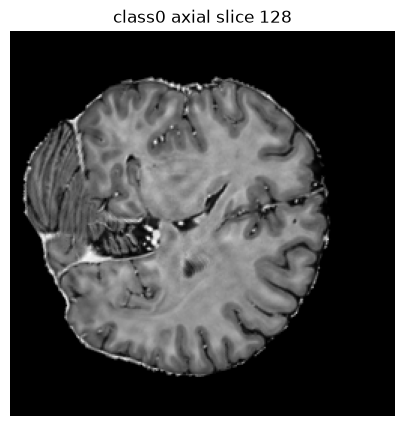

Volume: (256, 256, 256) range: (0.0, 1.0)


In [1]:
%matplotlib inline
import json
from pathlib import Path
from IPython.display import display, Image as DisplayImage

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch

file_path = Path('data/class0/aadd_00000.nii.gz')
assert file_path.exists(), f'Missing: {file_path.resolve()}'
img = nib.as_closest_canonical(nib.load(file_path))
volume = img.get_fdata(dtype=np.float32)
volume = (volume - volume.min()) / max(float(volume.max() - volume.min()), 1e-8)
middle = volume.shape[2] // 2
plt.figure(figsize=(5, 5))
plt.imshow(volume[:, :, middle], cmap='gray')
plt.title(f'class0 axial slice {middle}')
plt.axis('off')
plt.show()
print('Volume:', volume.shape, 'range:', (float(volume.min()), float(volume.max())))


# Model: DINO dense and global representations

The tutorial suggests DINOv3. Its official weights are gated and require accepting Meta's access terms. This executable version uses the public `facebook/dinov2-small` fallback, which exposes the same representations needed here: a global CLS token, self-attention matrices, and patch tokens.

After DINOv3 access is granted, set the environment variable `DINO_MODEL_ID=facebook/dinov3-vits16-pretrain-lvd1689m` before running the script. The code selects the final spatial patch tokens, so it also handles DINOv3 register tokens.


In [2]:
import sys
import subprocess
from pathlib import Path

workspace_python = Path.cwd() / '.venv/bin/python'
if not workspace_python.exists():
    raise FileNotFoundError(f'Workspace Python not found: {workspace_python}')

print('Notebook sys.executable:', sys.executable)
print('Notebook sys.prefix:', sys.prefix)
print('Tutorial subprocess Python:', workspace_python)

# Verify Transformers in the exact interpreter used for the tutorial script.
subprocess.run(
    [str(workspace_python), '-c',
     'import sys, transformers; print("Subprocess:", sys.executable); '
     'print("Subprocess prefix:", sys.prefix); print("Transformers:", transformers.__version__)'],
    check=True,
)


Notebook sys.executable: /config/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv/bin/python
Notebook sys.prefix: /config/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv
Tutorial subprocess Python: /config/workspace/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv/bin/python
Subprocess: /config/workspace/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv/bin/python
Subprocess prefix: /config/workspace/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv
Transformers: 5.15.1


CompletedProcess(args=['/config/workspace/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv/bin/python', '-c', 'import sys, transformers; print("Subprocess:", sys.executable); print("Subprocess prefix:", sys.prefix); print("Transformers:", transformers.__version__)'], returncode=0)

In [3]:
# Use the workspace environment explicitly, independent of the notebook kernel.
subprocess.run(
    [str(workspace_python), 'tutorial2_self_supervision.py'],
    check=True,
)


[TRACE 1/7] Loading class0 slices
[TRACE 2/7] Loading frozen DINO facebook/dinov2-small


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 5591.34it/s]


DINO CLS matrix: (30, 384) seconds: 6.32
[TRACE 3/7] Attention and PCA patch maps
[TRACE 4/7] UMAP and image-space comparison


/config/workspace/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[TRACE 5/7] Building rotation-prediction pretext dataset
[TRACE 6/7] Training tailored rotation task
epoch=1 validation_accuracy=0.313
epoch=2 validation_accuracy=0.831
epoch=3 validation_accuracy=0.910
epoch=4 validation_accuracy=0.952
epoch=5 validation_accuracy=0.976
epoch=6 validation_accuracy=0.970
epoch=7 validation_accuracy=0.928
epoch=8 validation_accuracy=0.946
[TRACE 7/7] Complete
{
  "dino_model": "facebook/dinov2-small",
  "dino_parameters": 22056576,
  "processed_slices": 30,
  "dino_seconds": 6.31579190120101,
  "cls_shape": [
    30,
    384
  ],
  "dino_proxy_silhouette": 0.07312404364347458,
  "raw_image_proxy_silhouette": 0.16574065387248993,
  "rotation_parameters": 137284,
  "rotation_validation_accuracy": 0.9457831325301205,
  "warning": "Slice-position thirds are proxy groups, not diagnostic classes."
}


CompletedProcess(args=['/config/workspace/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv/bin/python', 'tutorial2_self_supervision.py'], returncode=0)

In [4]:
tutorial2_output = Path('outputs/tutorial2')
tutorial2_metrics = json.loads((tutorial2_output / 'metrics.json').read_text())
for key, value in tutorial2_metrics.items():
    print(f'{key}: {value}')


dino_model: facebook/dinov2-small
dino_parameters: 22056576
processed_slices: 30
dino_seconds: 6.31579190120101
cls_shape: [30, 384]
dino_proxy_silhouette: 0.07312404364347458
raw_image_proxy_silhouette: 0.16574065387248993
rotation_parameters: 137284
rotation_validation_accuracy: 0.9457831325301205


## 1. CLS-token attention

The overlay averages the final-layer attention from the CLS query to all spatial patches. Check whether high-attention areas correspond to anatomy rather than background or fixed image positions. Attention is descriptive, not a validated segmentation or causal explanation.


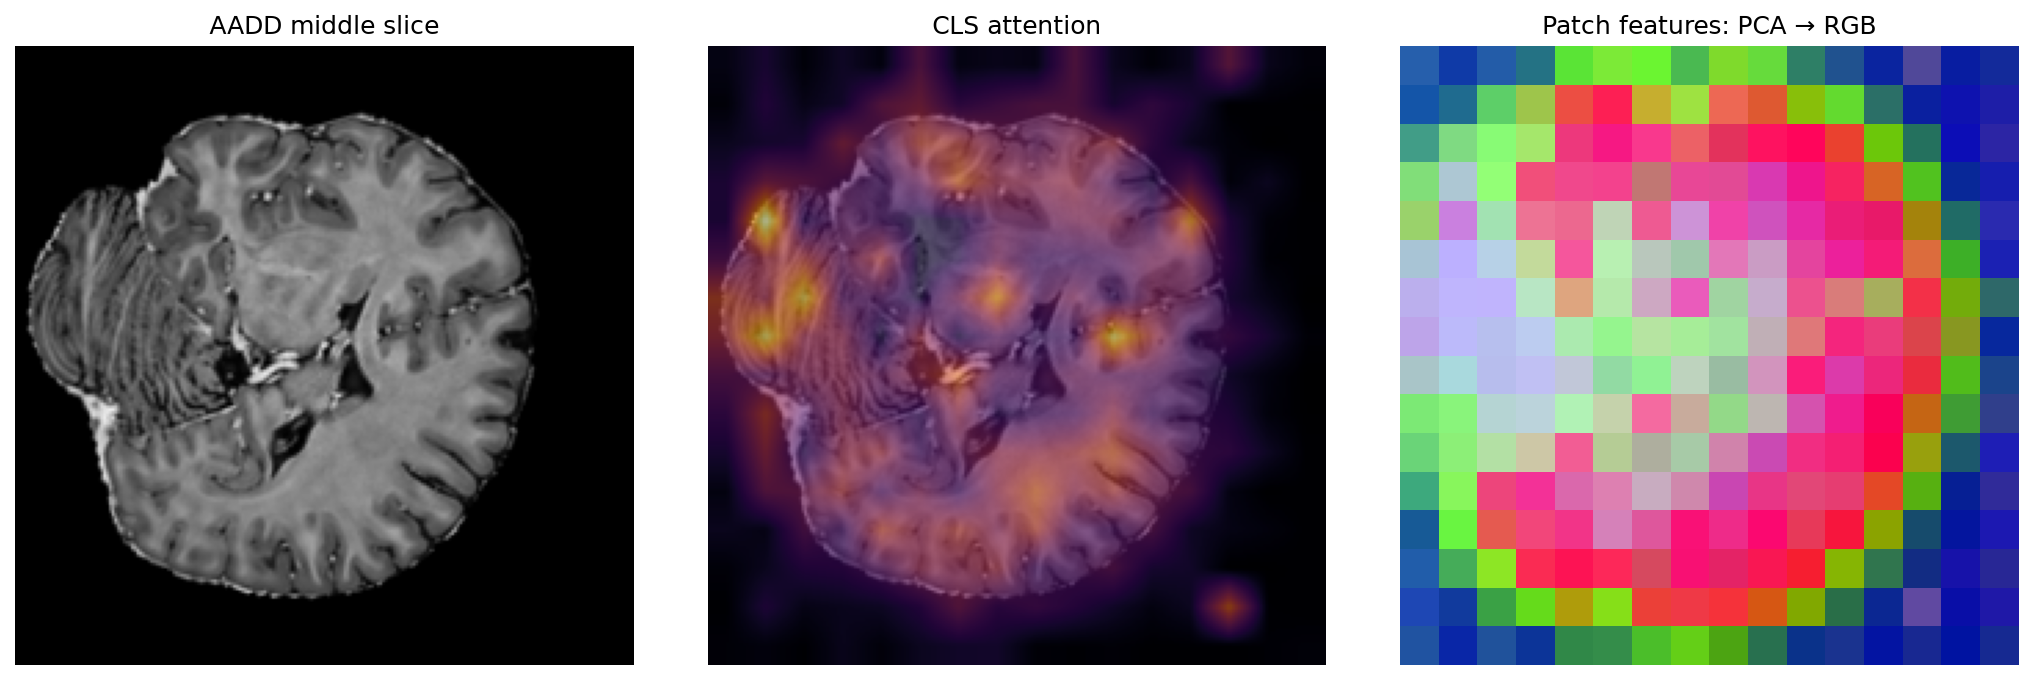

In [5]:
display(DisplayImage(filename=str(tutorial2_output / 'medical_attention_pca.png')))


## 2. Contextualized patch embeddings reduced with PCA

The right panel maps the first three principal components of the patch embeddings to RGB. Similar colors mean similar DINO features within this one image. Look for consistency within tissue regions and transitions at boundaries; the 14-pixel patches limit granularity.


## 3. Natural-image comparison

DINO was pretrained on natural/web imagery. Comparing the medical slice with a natural image reveals whether attention and PCA colors are more object-centered in-domain and more influenced by image position or gross intensity out-of-domain.


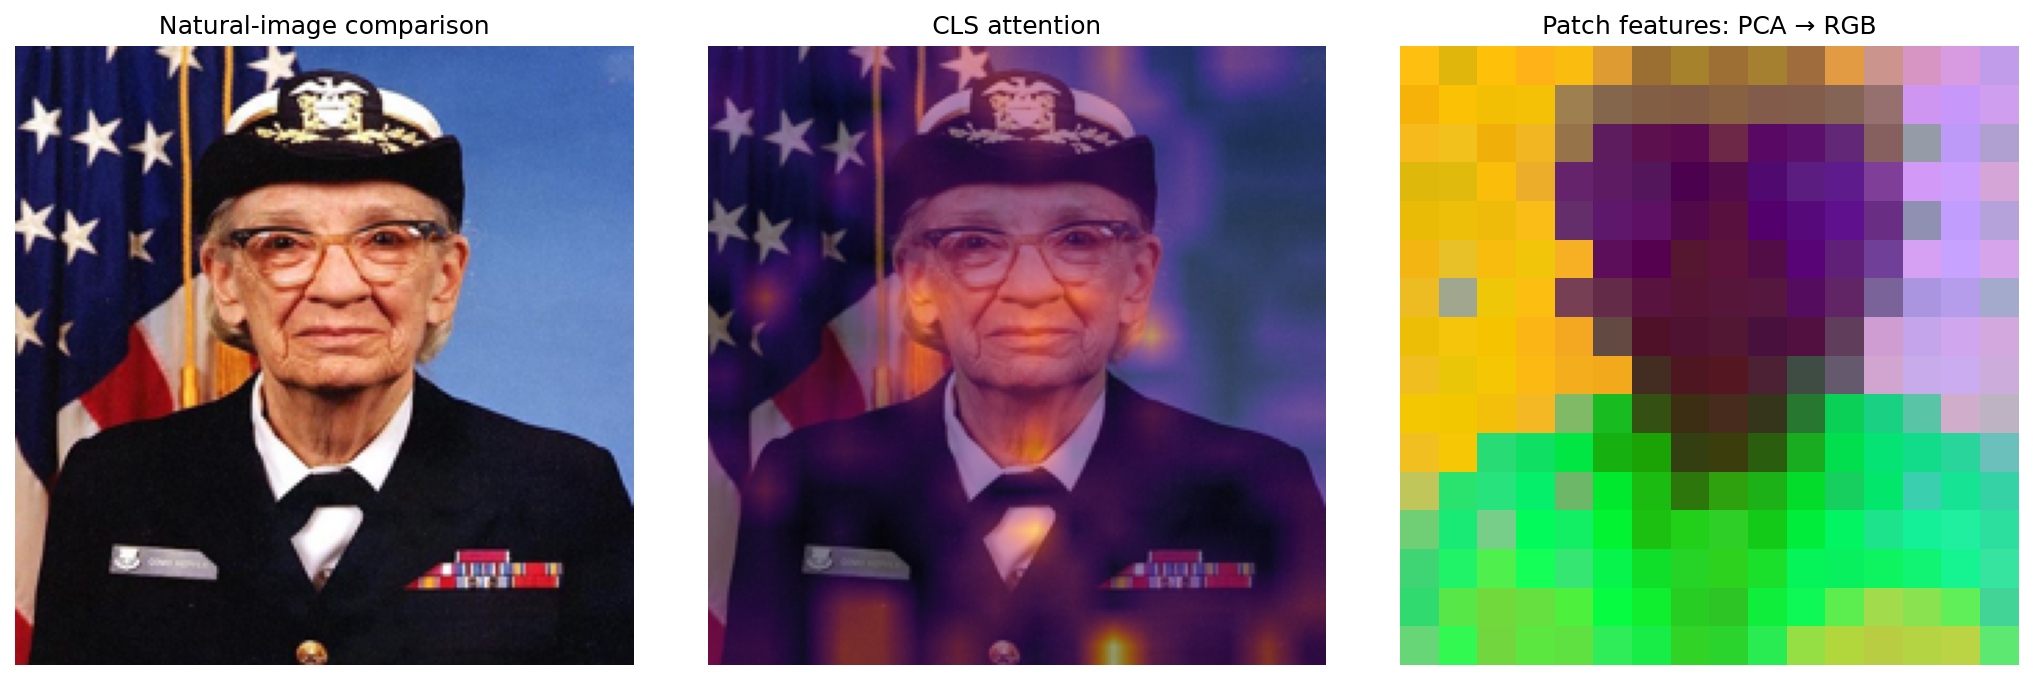

In [6]:
display(DisplayImage(filename=str(tutorial2_output / 'natural_attention_pca.png')))


# Analysis: global slice representations

CLS tokens from 30 slices are reduced with UMAP and colored by slice-position proxy group. This is an exploratory continuity test, not class evaluation.


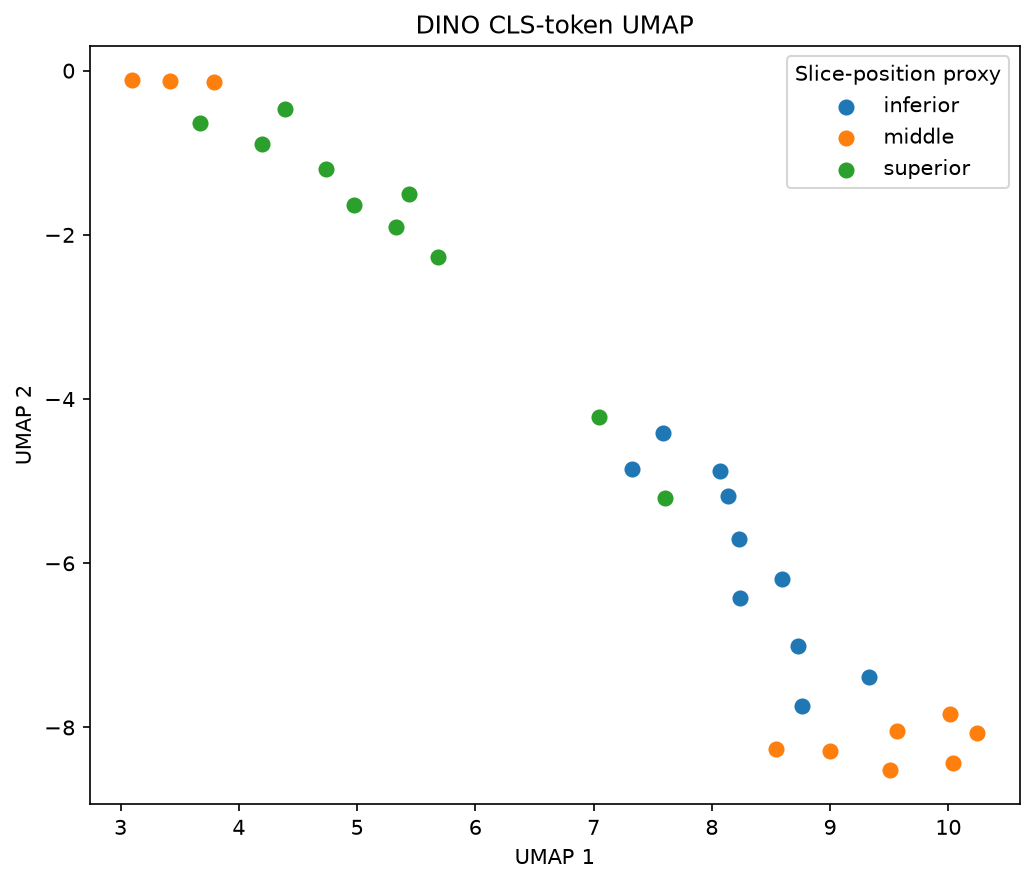

DINO proxy silhouette: 0.073
Raw-image proxy silhouette: 0.166


In [7]:
display(DisplayImage(filename=str(tutorial2_output / 'dino_cls_umap.png')))
print(f"DINO proxy silhouette: {tutorial2_metrics['dino_proxy_silhouette']:.3f}")
print(f"Raw-image proxy silhouette: {tutorial2_metrics['raw_image_proxy_silhouette']:.3f}")


### Interpretation

For this run, DINO's proxy silhouette is **0.073**, below the raw-image value of **0.166**. Thus the frozen natural-image DINO representation does not provide an advantage for separating coarse anatomical slice positions in this single scan. This may reflect domain shift, grayscale replication, limited sample size, or the fact that slice position is strongly encoded by raw anatomy. True class conclusions require independent volumes from multiple classes.


# Tailored self-supervised task: rotation prediction

We create labels automatically by rotating each slice by 0°, 90°, 180°, or 270°. A small CNN must retain global orientation and asymmetric anatomical layout to solve the task. This is self-supervised because the transformation supplies the target without manual labels.

An initial model with global average pooling stayed at chance because pooling erased spatial arrangement. Preserving the final `8×8` feature grid corrected that failure—an example of matching architecture to the pretext task.


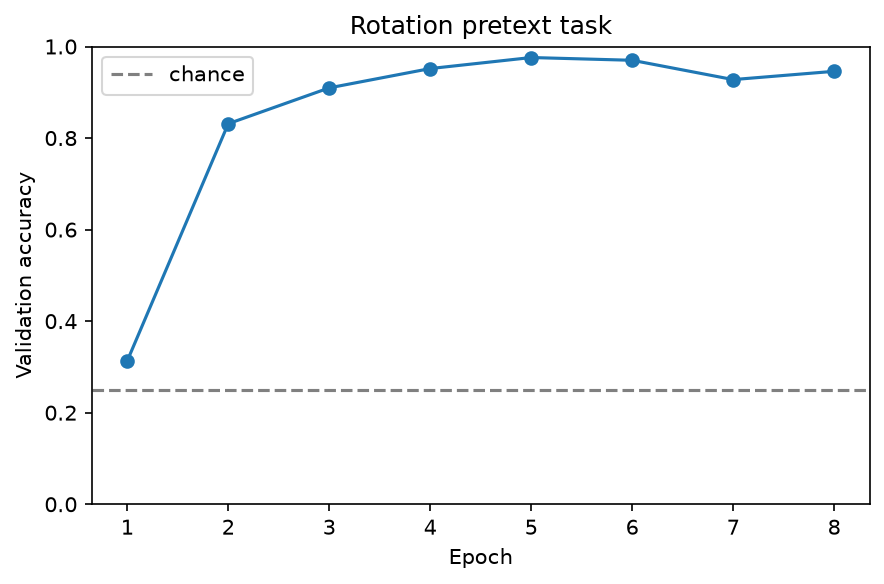

Rotation validation accuracy: 94.6%
Rotation-network parameters: 137284


In [8]:
display(DisplayImage(filename=str(tutorial2_output / 'rotation_training.png')))
print(f"Rotation validation accuracy: {tutorial2_metrics['rotation_validation_accuracy']:.1%}")
print('Rotation-network parameters:', tutorial2_metrics['rotation_parameters'])


### Tailored-task result and limitations

The 137,284-parameter network reaches approximately **94.6%** validation accuracy, so the pretext task successfully forces orientation-sensitive features. However, rotated versions of the same source slices were randomly split across train and validation; this evaluates the transformation task, not subject-level generalization. With multiple scans, split by volume before augmentation.
